# **1. Perkenalan Dataset**


## Dataset: Stroke Prediction Dataset

**Sumber:** [Kaggle — fedesoriano/stroke-prediction-dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

**Deskripsi:**  
Dataset ini berisi informasi klinis dan demografis pasien yang digunakan untuk memprediksi apakah seorang pasien berpotensi mengalami **stroke** atau tidak. Stroke merupakan penyebab kematian dan kecacatan kedua terbesar di dunia, sehingga prediksi dini sangat penting.

**Detail Dataset:**
- **Jumlah baris:** 5.110
- **Jumlah kolom:** 12
- **Task:** Binary Classification (`stroke`: 0 = tidak stroke, 1 = stroke)
- **Format:** CSV

| Kolom | Tipe | Deskripsi |
|---|---|---|
| id | int | ID unik pasien (tidak digunakan dalam model) |
| gender | kategorikal | Jenis kelamin (Male / Female / Other) |
| age | numerik | Usia pasien |
| hypertension | biner | 1 jika pasien hipertensi, 0 jika tidak |
| heart_disease | biner | 1 jika pasien memiliki penyakit jantung, 0 jika tidak |
| ever_married | kategorikal | Status pernikahan (Yes / No) |
| work_type | kategorikal | Jenis pekerjaan |
| Residence_type | kategorikal | Tipe tempat tinggal (Urban / Rural) |
| avg_glucose_level | numerik | Rata-rata kadar gula darah |
| bmi | numerik | Body Mass Index (**terdapat 201 missing values**) |
| smoking_status | kategorikal | Status merokok |
| **stroke** | **biner** | **Target** — 1 jika pernah stroke, 0 jika tidak |


# **2. Import Library**

In [1]:
# === Data Manipulation ===
import pandas as pd
import numpy as np

# === Visualisasi ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Preprocessing ===
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# === Utilitas ===
import warnings
import os
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Semua library berhasil diimport!
Pandas  : 2.2.2
NumPy   : 2.0.2


# **3. Memuat Dataset**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download('fedesoriano/stroke-prediction-dataset')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [3]:
# Cek isi folder dataset
print('File tersedia:', os.listdir(path))

# Muat dataset ke DataFrame
df = pd.read_csv(os.path.join(path, 'healthcare-dataset-stroke-data.csv'))

print(f'\nDataset berhasil dimuat!')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'Kolom         : {df.columns.tolist()}')

File tersedia: ['healthcare-dataset-stroke-data.csv']

Dataset berhasil dimuat!
Jumlah baris  : 5110
Jumlah kolom  : 12
Kolom         : ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [4]:
# Tampilkan 5 baris pertama
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **4. Exploratory Data Analysis (EDA)**

## 4.1 Informasi Umum Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## 4.2 Statistik Deskriptif

In [6]:
df.describe().round(2)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


## 4.3 Pengecekan Missing Values & Duplikat

In [7]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'\n=== Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== Missing Values ===
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Total missing: 201

=== Duplikat ===
Jumlah baris duplikat: 0


## 4.4 Distribusi Variabel Target (stroke)

In [8]:
print('Distribusi stroke:')
print(df['stroke'].value_counts())
print('\nProsentase:')
print(df['stroke'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Distribusi stroke:
stroke
0    4861
1     249
Name: count, dtype: int64

Prosentase:
stroke
0    95.13 %
1     4.87 %
Name: proportion, dtype: object


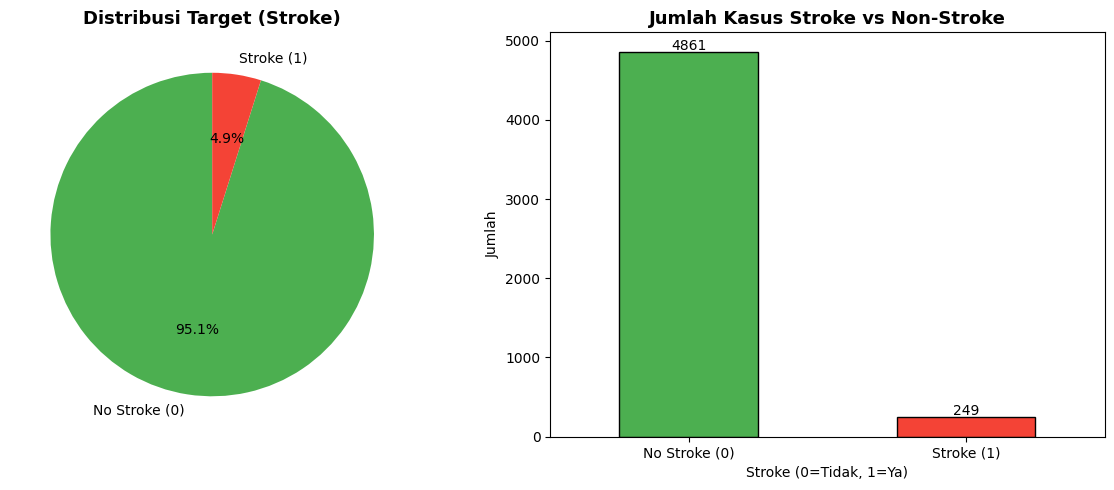

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stroke_counts = df['stroke'].value_counts()

axes[0].pie(stroke_counts, labels=['No Stroke (0)', 'Stroke (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Distribusi Target (Stroke)', fontsize=13, fontweight='bold')

stroke_counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'], edgecolor='black')
axes[1].set_title('Jumlah Kasus Stroke vs Non-Stroke', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Stroke (0=Tidak, 1=Ya)')
axes[1].set_ylabel('Jumlah')
axes[1].set_xticklabels(['No Stroke (0)', 'Stroke (1)'], rotation=0)
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())), (p.get_x()+p.get_width()/2., p.get_height()+20), ha='center')

plt.tight_layout()
plt.show()

## 4.5 Distribusi Fitur Numerik

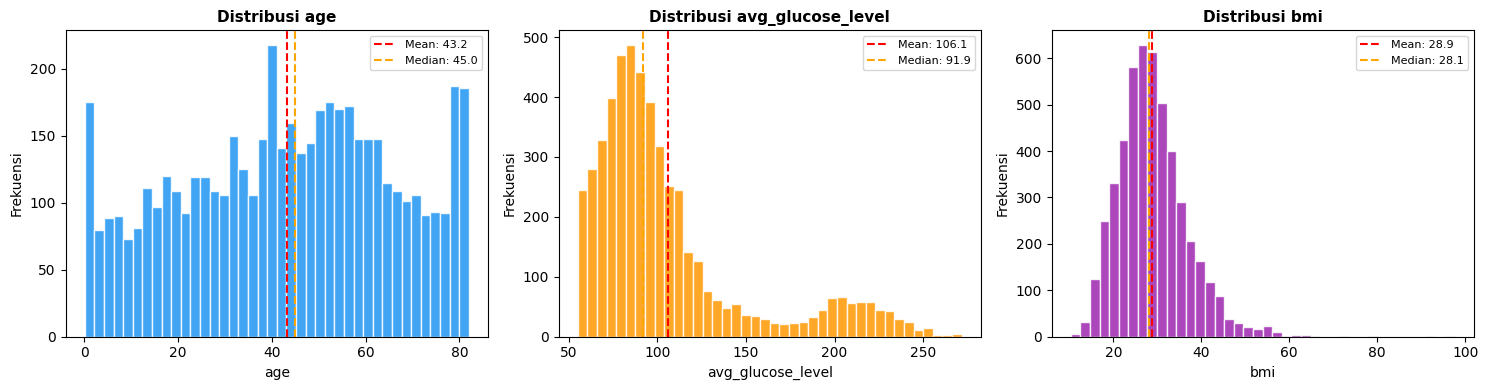

In [10]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2196F3', '#FF9800', '#9C27B0']

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Insight:**
- `age`: distribusi relatif merata dengan rentang 0.08 – 82 tahun, mean ± 43.2 tahun.
- `avg_glucose_level`: distribusi right-skewed, banyak nilai tinggi (potensi outlier).
- `bmi`: distribusi mendekati normal, terdapat 201 missing values yang perlu ditangani.


## 4.6 Distribusi Fitur Kategorikal

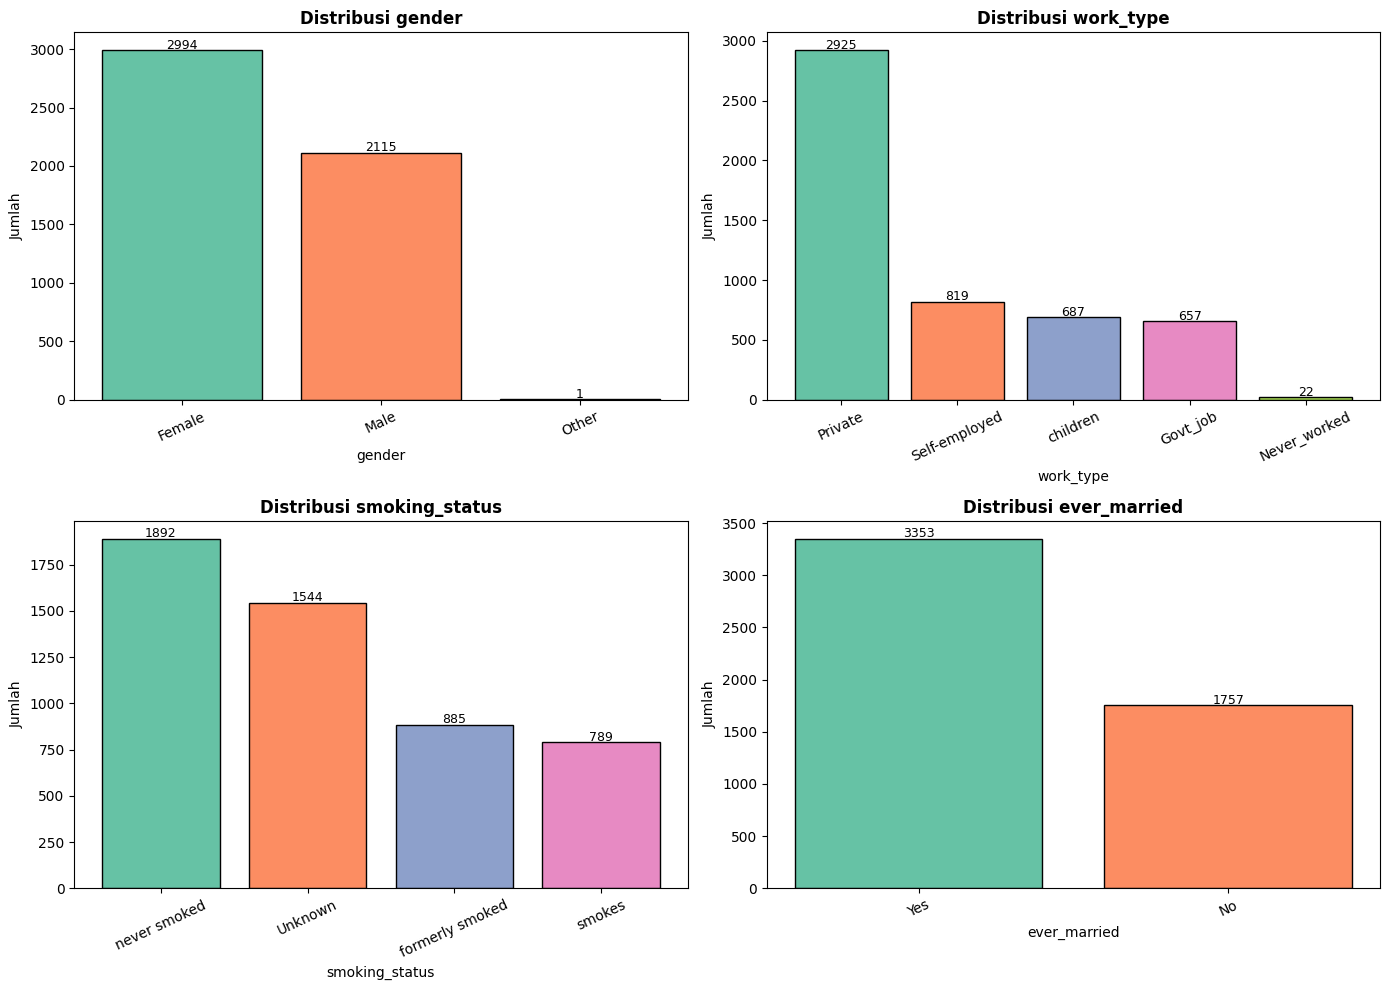

In [11]:
cat_cols = ['gender', 'work_type', 'smoking_status', 'ever_married']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pal = sns.color_palette('Set2')

for i, col in enumerate(cat_cols):
    r, c = i // 2, i % 2
    vc = df[col].value_counts()
    axes[r][c].bar(vc.index, vc.values, color=pal[:len(vc)], edgecolor='black')
    axes[r][c].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[r][c].set_xlabel(col)
    axes[r][c].set_ylabel('Jumlah')
    axes[r][c].tick_params(axis='x', rotation=25)
    for j, v in enumerate(vc.values):
        axes[r][c].text(j, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4.7 Matriks Korelasi

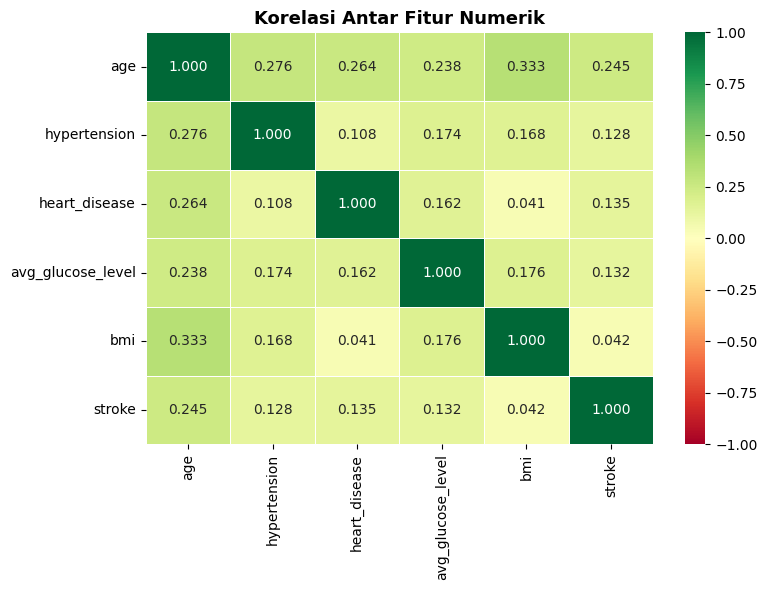

In [12]:
num_df = df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']].copy()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
ax.set_title('Korelasi Antar Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- `age` memiliki korelasi tertinggi dengan `stroke` (0.245), diikuti `hypertension` (0.127) dan `heart_disease` (0.131).
- Tidak ada multikolinearitas tinggi antar fitur numerik.


## 4.8 Deteksi Outlier (Boxplot)

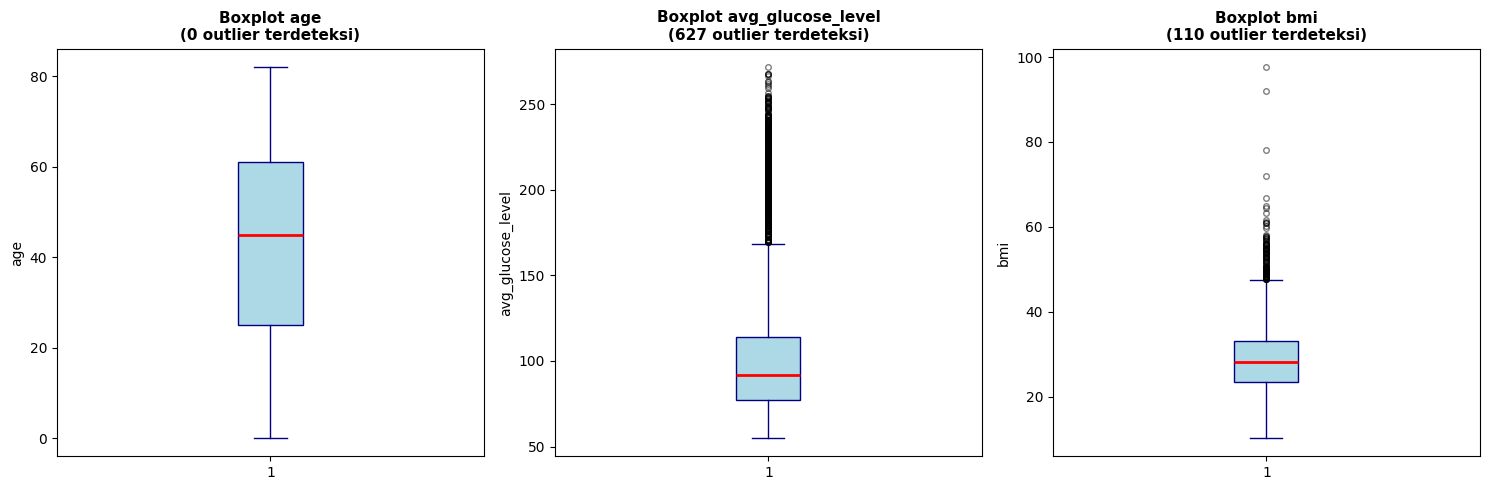

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
num_cols = ['age', 'avg_glucose_level', 'bmi']

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='navy'),
                    capprops=dict(color='navy'),
                    flierprops=dict(marker='o', color='red', alpha=0.5, markersize=4))
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    axes[i].set_title(f'Boxplot {col}\n({len(outliers)} outlier terdeteksi)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 4.9 Distribusi Usia berdasarkan Status Stroke

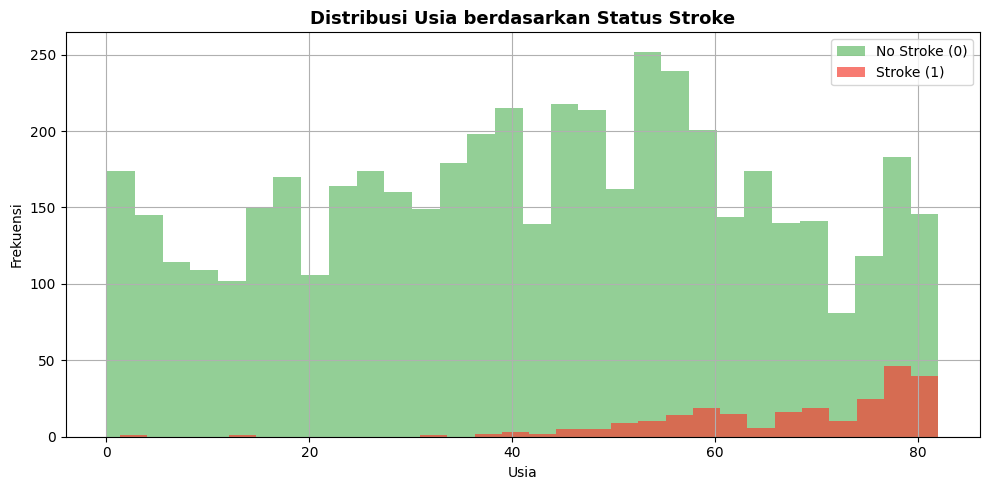

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
df[df['stroke']==0]['age'].hist(bins=30, alpha=0.6, ax=ax, color='#4CAF50', label='No Stroke (0)')
df[df['stroke']==1]['age'].hist(bins=30, alpha=0.7, ax=ax, color='#F44336', label='Stroke (1)')
ax.set_title('Distribusi Usia berdasarkan Status Stroke', fontsize=13, fontweight='bold')
ax.set_xlabel('Usia')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Pasien yang mengalami stroke mayoritas berusia di atas 50 tahun, memperkuat bahwa `age` adalah fitur prediktor utama.


# **5. Data Preprocessing**

Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan preprocessing yang dilakukan:
1. **Drop kolom `id`** — tidak relevan untuk pemodelan
2. **Menangani Missing Values** — imputasi median pada kolom `bmi`
3. **Menghapus Duplikat** — memastikan tidak ada data ganda
4. **Menghapus noise** — menghapus baris dengan `gender='Other'` (hanya 1 baris)
5. **Deteksi dan Penanganan Outlier** — IQR capping pada `avg_glucose_level` dan `bmi`
6. **Encoding** — Label Encoding (binary) dan One-Hot Encoding (multi-class)
7. **Normalisasi** — StandardScaler pada fitur numerik


## 5.1 Drop Kolom `id`

In [15]:
df_clean = df.copy()

df_clean.drop(columns=['id'], inplace=True)
print(f'Shape setelah drop id: {df_clean.shape}')
print(f'Kolom tersisa: {df_clean.columns.tolist()}')

Shape setelah drop id: (5110, 11)
Kolom tersisa: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


## 5.2 Menangani Missing Values

In [16]:
# Imputasi bmi dengan nilai median
bmi_median = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)

print(f'Median BMI untuk imputasi: {bmi_median}')
print(f'Missing values setelah imputasi:')
print(df_clean.isnull().sum())

Median BMI untuk imputasi: 28.1
Missing values setelah imputasi:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


## 5.3 Menghapus Data Duplikat

In [17]:
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Baris sebelum: {before} | Setelah: {len(df_clean)} | Dihapus: {before - len(df_clean)}')

Baris sebelum: 5110 | Setelah: 5110 | Dihapus: 0


## 5.4 Menghapus Noise (gender = 'Other')

In [18]:
print(f"Nilai unik gender: {df_clean['gender'].unique()}")
print(f"Jumlah gender='Other': {(df_clean['gender']=='Other').sum()}")

before = len(df_clean)
df_clean = df_clean[df_clean['gender'] != 'Other'].reset_index(drop=True)
print(f'\nBaris setelah hapus Other: {len(df_clean)} (berkurang {before - len(df_clean)} baris)')

Nilai unik gender: ['Male' 'Female' 'Other']
Jumlah gender='Other': 1

Baris setelah hapus Other: 5109 (berkurang 1 baris)


## 5.5 Penanganan Outlier (IQR Capping)

In [19]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  '{col}': {n_outlier} outlier di-cap ke [{lower:.2f}, {upper:.2f}]")
    return df

print('Hasil IQR Capping:')
for col in ['avg_glucose_level', 'bmi']:
    df_clean = cap_outliers_iqr(df_clean, col)

print(f'\nStatistik setelah capping:')
print(df_clean[['avg_glucose_level', 'bmi']].describe().round(2))

Hasil IQR Capping:
  'avg_glucose_level': 627 outlier di-cap ke [21.96, 169.37]
  'bmi': 126 outlier di-cap ke [10.30, 46.30]

Statistik setelah capping:
       avg_glucose_level      bmi
count            5109.00  5109.00
mean              100.99    28.69
std                33.21     7.12
min                55.12    10.30
25%                77.24    23.80
50%                91.88    28.10
75%               114.09    32.80
max               169.36    46.30


## 5.6 Encoding Data Kategorikal

In [20]:
le = LabelEncoder()

# Label Encoding untuk kolom biner
binary_cols = ['gender', 'ever_married', 'Residence_type']
for col in binary_cols:
    orig_classes = sorted(df_clean[col].unique())
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Label Encoding '{col}': {dict(zip(orig_classes, range(len(orig_classes))))}")

# One-Hot Encoding untuk multi-class
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=False)

# Ubah boolean ke int
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f'\nShape setelah encoding: {df_clean.shape}')
print(f'Kolom baru: {df_clean.columns.tolist()}')

Label Encoding 'gender': {'Female': 0, 'Male': 1}
Label Encoding 'ever_married': {'No': 0, 'Yes': 1}
Label Encoding 'Residence_type': {'Rural': 0, 'Urban': 1}

Shape setelah encoding: (5109, 18)
Kolom baru: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


## 5.7 Normalisasi / Standarisasi Fitur

In [21]:
scaler = StandardScaler()
scale_cols = ['age', 'avg_glucose_level', 'bmi']

df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print('Statistik fitur setelah StandardScaler:')
print(df_clean[scale_cols].describe().round(4))

Statistik fitur setelah StandardScaler:
             age  avg_glucose_level        bmi
count  5109.0000          5109.0000  5109.0000
mean      0.0000            -0.0000    -0.0000
std       1.0001             1.0001     1.0001
min      -1.9083            -1.3811    -2.5830
25%      -0.8062            -0.7151    -0.6870
50%       0.0783            -0.2743    -0.0831
75%       0.7859             0.3945     0.5770
max       1.7146             2.0588     2.4730


## 5.8 Hasil Akhir & Simpan Dataset

In [22]:
print('=== RINGKASAN PREPROCESSING ===')
print(f'Shape awal  : (5110, 12)')
print(f'Shape akhir : {df_clean.shape}')
print(f'Total NaN   : {df_clean.isnull().sum().sum()}')
print(f'\nDistribusi target:')
print(df_clean['stroke'].value_counts())
print(f'\n5 baris pertama dataset final:')
df_clean.head()

=== RINGKASAN PREPROCESSING ===
Shape awal  : (5110, 12)
Shape akhir : (5109, 18)
Total NaN   : 0

Distribusi target:
stroke
0    4860
1     249
Name: count, dtype: int64

5 baris pertama dataset final:


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,1.051242,0,1,1,1,2.058819,1.110675,1,0,0,1,0,0,0,1,0,0
1,0,0.785889,0,0,1,0,2.058819,-0.083092,1,0,0,0,1,0,0,0,1,0
2,1,1.626174,0,1,1,0,0.148478,0.534858,1,0,0,1,0,0,0,0,1,0
3,0,0.255182,0,0,1,1,2.058819,0.801700,1,0,0,1,0,0,0,0,0,1
4,0,1.581949,1,0,1,0,2.058819,-0.658909,1,0,0,0,1,0,0,0,1,0


In [23]:
# Simpan dataset hasil preprocessing
df_clean.to_csv('stroke_preprocessing.csv', index=False)
print('Dataset preprocessing berhasil disimpan: stroke_preprocessing.csv')
print(f'Shape tersimpan: {df_clean.shape}')

Dataset preprocessing berhasil disimpan: stroke_preprocessing.csv
Shape tersimpan: (5109, 18)
